In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ucimachinelearning/otoscopic-image-dataset")

print("Path to dataset files:", path)


100%|██████████| 86.6M/86.6M [00:01<00:00, 82.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ucimachinelearning/otoscopic-image-dataset/versions/1


In [ ]:
import os

print(os.listdir(path))




['Otoscopic_Data']


In [ ]:
dataset_path = path + "/Otoscopic_Data"
print(os.listdir(dataset_path))

['Cerumen Impaction', 'Chronic Otitis Media', 'Normal', 'Myringosclerosis', 'Acute Otitis Media']


(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

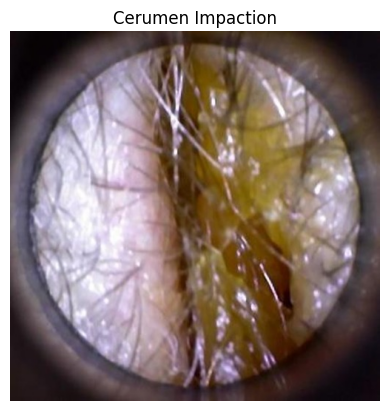

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

sample_class = os.listdir(dataset_path)[0]
sample_img = os.listdir(os.path.join(dataset_path, sample_class))[0]

img_path = os.path.join(dataset_path, sample_class, sample_img)

img = Image.open(img_path)

plt.imshow(img)
plt.title(sample_class)
plt.axis("off")


In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import os

# Define transformations for the images
# Common transforms include resizing, converting to tensor, and normalization.
# Normalization parameters are for ImageNet, often used with pre-trained models.
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224 pixels (common input size for many CNNs)
    transforms.RandomHorizontalFlip(), # Add random horizontal flip for data augmentation
    transforms.RandomRotation(15),     # Add random rotation for data augmentation
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1), # Add color jitter for more augmentation
    transforms.ToTensor(),         # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize pixel values
])

# Load the dataset using ImageFolder
# dataset_path is already defined from previous steps
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

print(f"Total number of images in the dataset: {len(full_dataset)}")
print(f"Classes found: {full_dataset.classes}")

Total number of images in the dataset: 3000
Classes found: ['Acute Otitis Media', 'Cerumen Impaction', 'Chronic Otitis Media', 'Myringosclerosis', 'Normal']


In [ ]:

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size


train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Number of images in training set: {len(train_dataset)}")
print(f"Number of images in validation set: {len(val_dataset)}")
print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(val_loader)}")


Number of images in training set: 2400
Number of images in validation set: 600
Number of batches in training loader: 75
Number of batches in validation loader: 19


In [ ]:
import timm
import torch.nn as nn

# Loading a pretrained Vision Transformer model
# Using 'vit_base_patch16_224' as a common choice
vit_model = timm.create_model('vit_base_patch16_224', pretrained=True)


num_classes = len(full_dataset.classes)


vit_model.head = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(vit_model.head.in_features, num_classes)
)

print(f"Model loaded and classification head modified for {num_classes} classes.")
print(vit_model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model loaded and classification head modified for 5 classes.
VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(appr

In [ ]:
import torch.optim as optim

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move the model to the defined device
vit_model.to(device)

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
# Added weight_decay for L2 regularization to prevent overfitting
optimizer = optim.Adam(vit_model.parameters(), lr=0.0001, weight_decay=1e-5) # You can adjust the learning rate (lr)

# Set the model to training mode
vit_model.train()
print("Model, criterion, and optimizer are set up and model is in training mode.")

Using device: cuda
Model, criterion, and optimizer are set up and model is in training mode.


In [ ]:
import torch.optim.lr_scheduler as lr_scheduler

num_epochs = 1


scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

for epoch in range(num_epochs):
    vit_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)


        optimizer.zero_grad()


        outputs = vit_model(inputs)
        loss = criterion(outputs, labels)


        loss.backward()
        optimizer.step()

        running_loss += loss.item()


        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    print(f'Epoch {epoch+1}, Training Loss: {running_loss/len(train_loader):.4f}, Training Accuracy: {train_accuracy:.2f}%')


    vit_model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vit_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accuracy = 100 * correct_val / total_val
    print(f'Epoch {epoch+1}, Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_accuracy:.2f}%')


    scheduler.step()

print('Finished Training!')

Epoch 1, Training Loss: 0.4919, Training Accuracy: 80.25%
Epoch 1, Validation Loss: 0.1230, Validation Accuracy: 94.00%
Epoch 2, Training Loss: 0.0687, Training Accuracy: 97.71%
Epoch 2, Validation Loss: 0.0212, Validation Accuracy: 99.50%
Epoch 3, Training Loss: 0.0745, Training Accuracy: 97.62%
Epoch 3, Validation Loss: 0.0281, Validation Accuracy: 99.33%
Finished Training!


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving symptom_dataset_500_rows_v2.csv to symptom_dataset_500_rows_v2.csv


In [ ]:
import pandas as pd

df = pd.read_csv("symptom_dataset_500_rows_v2.csv")

df.head()


,pain,discharge,hearing_loss,fever,blocked_ear,itching,dizziness,tinnitus,long_duration,label
0,0,0,0,0,0,0,0,0,0,normal
1,0,0,1,0,0,0,1,1,0,myringosclerosis
2,0,0,1,0,1,1,0,0,0,earwax
3,1,1,1,1,0,0,0,0,1,com
4,0,0,0,0,0,0,0,0,0,normal


In [ ]:
df.shape


(500, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pain           500 non-null    int64 
 1   discharge      500 non-null    int64 
 2   hearing_loss   500 non-null    int64 
 3   fever          500 non-null    int64 
 4   blocked_ear    500 non-null    int64 
 5   itching        500 non-null    int64 
 6   dizziness      500 non-null    int64 
 7   tinnitus       500 non-null    int64 
 8   long_duration  500 non-null    int64 
 9   label          500 non-null    object
dtypes: int64(9), object(1)
memory usage: 39.2+ KB


In [ ]:
df.isnull().sum()

,0
pain,0
discharge,0
hearing_loss,0
fever,0
blocked_ear,0
itching,0
dizziness,0
tinnitus,0
long_duration,0
label,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

feature_columns = ['pain', 'discharge', 'hearing_loss', 'fever', 'blocked_ear', 'itching', 'dizziness', 'tinnitus', 'long_duration']

X = df[feature_columns]
y = df['label']

# Encoding target labels to numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Features (X) shape: {X.shape}")
print(f"Target (y_encoded) shape: {y_encoded.shape}")
print(f"Original labels: {label_encoder.classes_}")
print(f"Encoded labels: {label_encoder.transform(label_encoder.classes_)}")

Features (X) shape: (500, 9)
Target (y_encoded) shape: (500,)
Original labels: ['com' 'earwax' 'myringosclerosis' 'normal']
Encoded labels: [0 1 2 3]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=10)


model.fit(X_train, y_train)

print("RandomForestClassifier trained successfully.")

X_train shape: (400, 9)
X_test shape: (100, 9)
y_train shape: (400,)
y_test shape: (100,)
RandomForestClassifier trained successfully.


Test Accuracy: 1.0000

Classification Report:
                  precision    recall  f1-score   support

             com       1.00      1.00      1.00        25
          earwax       1.00      1.00      1.00        25
myringosclerosis       1.00      1.00      1.00        25
          normal       1.00      1.00      1.00        25

        accuracy                           1.00       100
       macro avg       1.00      1.00      1.00       100
    weighted avg       1.00      1.00      1.00       100



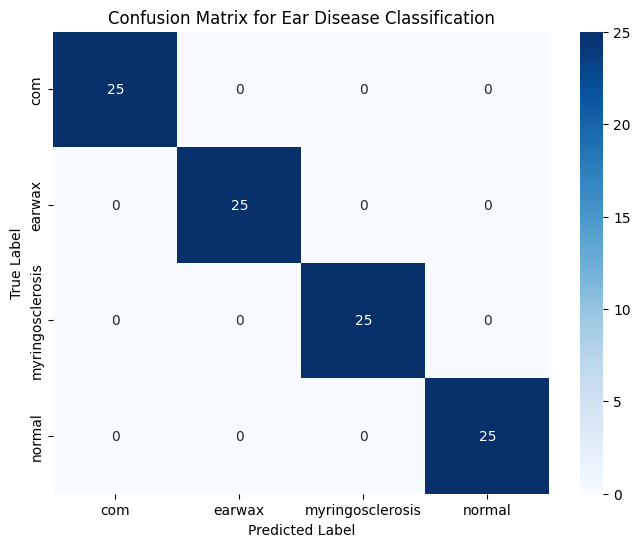

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Ear Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import torch
import torch.nn.functional as F


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    max_depth=10
)

rf_model.fit(X_train, y_train)

print("RandomForestClassifier trained.")



vit_model.eval()

correct_vit = 0
total_vit = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = vit_model(images)
        _, predicted = torch.max(outputs, 1)

        total_vit += labels.size(0)
        correct_vit += (predicted == labels).sum().item()

vit_accuracy = correct_vit / total_vit
print("\nViT Accuracy:", vit_accuracy)



rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)



combined_classes = full_dataset.classes  # 5 classes

rf_to_combined_map = {
    'com': combined_classes.index('Chronic Otitis Media'),
    'earwax': combined_classes.index('Cerumen Impaction'),
    'myringosclerosis': combined_classes.index('Myringosclerosis'),
    'normal': combined_classes.index('Normal')
}

weight_image = 0.8
weight_symptom = 0.2

correct = 0
total = len(X_test)

vit_model.eval()

val_iter = iter(val_loader)

for i in range(total):


    try:
        images, labels = next(val_iter)
    except StopIteration:
        val_iter = iter(val_loader)
        images, labels = next(val_iter)

    with torch.no_grad():
        image_inputs = images[0:1].to(device)
        image_outputs = vit_model(image_inputs)
        image_probabilities = F.softmax(image_outputs, dim=1).cpu().numpy()[0]


    symptom_data = X_test.iloc[i].values.reshape(1, -1)
    symptom_probabilities_rf = rf_model.predict_proba(symptom_data)[0]


    symptom_prob_aligned = np.zeros(len(combined_classes))

    for j, rf_class_name in enumerate(label_encoder.classes_):
        if rf_class_name in rf_to_combined_map:
            idx = rf_to_combined_map[rf_class_name]
            symptom_prob_aligned[idx] = symptom_probabilities_rf[j]


    final_probs = (weight_image * image_probabilities) + \
                  (weight_symptom * symptom_prob_aligned)

    final_pred = np.argmax(final_probs)
    final_predicted_class = combined_classes[final_pred]


RandomForestClassifier trained.

ViT Accuracy: 0.9833333333333333
Random Forest Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the training data for Random Forest
# Using X_train and y_train for cross-validation ensures no leakage from the test set.
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-Validation Scores (5-folds): {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


print(f"\nRandom Forest - Test Accuracy: {accuracy:.4f}")
print(f"Random Forest - Mean Cross-Validation Accuracy: {cv_scores.mean():.4f}")

if accuracy > cv_scores.mean():
    print("The Random Forest test accuracy is slightly higher than the mean cross-validation accuracy. This can happen due to random variations in the train/test split, or a 'lucky' test set.")
elif accuracy < cv_scores.mean():
    print("The Random Forest test accuracy is slightly lower than the mean cross-validation accuracy. This is also normal due to random variations.")
else:
    print("The Random Forest test accuracy is consistent with the mean cross-validation accuracy, indicating good generalization consistency.")


print(f"\nVision Transformer - Last Epoch Training Accuracy: {train_accuracy:.2f}%")
print(f"Vision Transformer - Last Epoch Validation Accuracy: {val_accuracy:.2f}%")

if train_accuracy > val_accuracy + 5: # A threshold for significant difference
    print("The Vision Transformer shows a noticeable difference between training and validation accuracy, suggesting some degree of overfitting to the training data despite augmentations and dropout.")
elif val_accuracy > train_accuracy + 5:
    print("Unexpected: Vision Transformer validation accuracy is significantly higher than training accuracy. This might indicate issues with data splits or evaluation metrics (e.g., small validation set causing high variance).")
else:
    print("The Vision Transformer's training and validation accuracies are relatively close for the last epoch, indicating good generalization without significant overfitting.")

Cross-Validation Scores (5-folds): [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0000
Standard Deviation: 0.0000

Random Forest - Test Accuracy: 1.0000
Random Forest - Mean Cross-Validation Accuracy: 1.0000
The Random Forest test accuracy is consistent with the mean cross-validation accuracy, indicating good generalization consistency.

Vision Transformer - Last Epoch Training Accuracy: 97.62%
Vision Transformer - Last Epoch Validation Accuracy: 99.33%
The Vision Transformer's training and validation accuracies are relatively close for the last epoch, indicating good generalization without significant overfitting.


In [ ]:
!pip install --upgrade pip
!pip install grad-cam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 27.0 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=d4f90f9376f4d566bebdcb6b33f27f2075680a6e32889d25fb0632a87f39e012
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [grad-cam]


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2

In [ ]:
import torch
import joblib

torch.save(vit_model.state_dict(), "vit_ear_model.pth")
print("Vision Transformer model saved as 'vit_ear_model.pth'")

joblib.dump(rf_model, "symptom_rf_model.pkl")
print("RandomForestClassifier model saved as 'symptom_rf_model.pkl'")

Vision Transformer model saved as 'vit_ear_model.pth'
RandomForestClassifier model saved as 'symptom_rf_model.pkl'


In [ ]:
from google.colab import files


files.download("vit_ear_model.pth")

files.download("symptom_rf_model.pkl")

print("Models should have been downloaded to your local system.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Models should have been downloaded to your local system.


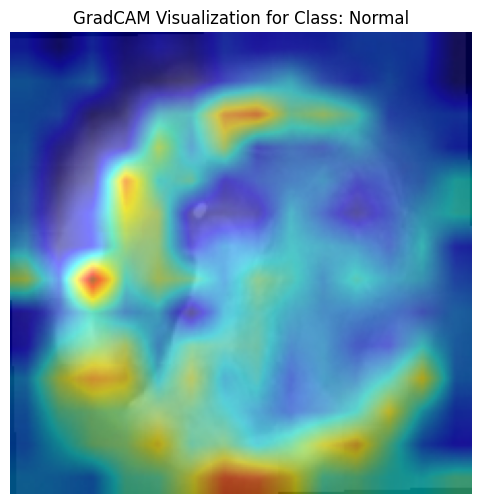

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2
import matplotlib.pyplot as plt


target_layers = [vit_model.patch_embed.proj]

cam = GradCAM(model=vit_model, target_layers=target_layers)


images, labels = next(iter(val_loader))
input_tensor = images[0].unsqueeze(0).to(device)


grayscale_cam = cam(input_tensor=input_tensor, targets=None)
grayscale_cam = grayscale_cam[0, :]


mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = input_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)
img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)


visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)


plt.figure(figsize=(8, 6))
plt.imshow(visualization)
plt.title(f"GradCAM Visualization for Class: {full_dataset.classes[labels[0]]}")
plt.axis('off')
plt.show()

In [ ]:
!pip install shap

In [ ]:
import shap
import matplotlib.pyplot as plt


explainer = shap.TreeExplainer(rf_model)


shap_values = explainer.shap_values(X_test)

print("SHAP values computed successfully.")

SHAP values computed successfully.


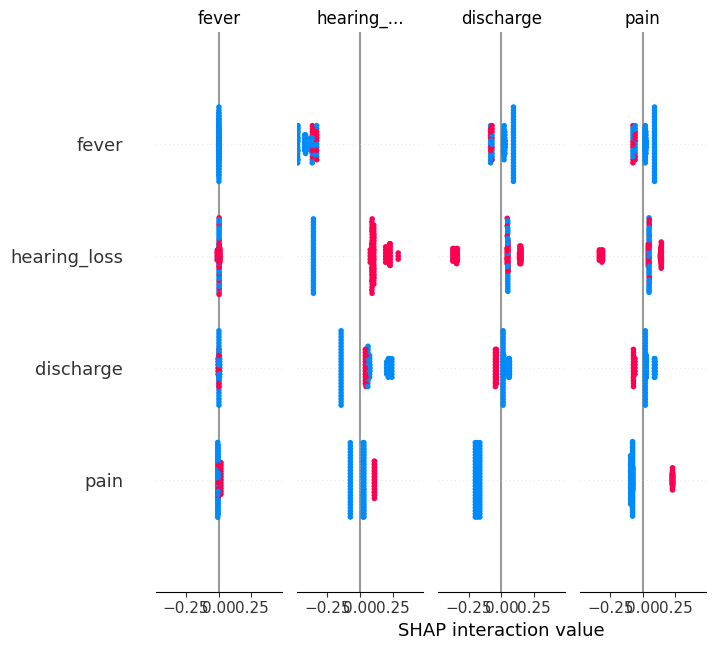

In [ ]:

if isinstance(shap_values, list):

    abs_shap_values = np.abs(np.array(shap_values)).mean(axis=0)
    shap.summary_plot(abs_shap_values, X_test, plot_type="bar", show=False)
    plt.title('SHAP Feature Importance (Mean Absolute SHAP Value)')
else:

    shap.summary_plot(shap_values, X_test, show=False)

plt.tight_layout()
plt.show()

In [ ]:

sample_index = 0




sample_prediction_encoded = rf_model.predict(X_test.iloc[[sample_index]])[0]
sample_prediction_class_name = label_encoder.inverse_transform([sample_prediction_encoded])[0]

print(f"Displaying force plot for sample {sample_index} (Actual: {label_encoder.inverse_transform([y_test[sample_index]])[0]}, Predicted: {sample_prediction_class_name})")


shap_values_for_sample = shap_values[sample_index][:, sample_prediction_encoded]

shap.initjs()
shap.force_plot(explainer.expected_value[sample_prediction_encoded] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value,
                 shap_values_for_sample,
                 X_test.iloc[sample_index],
                 feature_names=X_test.columns.tolist())

Displaying force plot for sample 0 (Actual: normal, Predicted: normal)


In [ ]:

!pip install -q google-generativeai

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import numpy as np


GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)


gemini_model = genai.GenerativeModel('gemini-flash-latest')

print("Gemini model initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini model initialized successfully.


In [ ]:
predicted_disease = final_predicted_class

sample_features = X_test.iloc[sample_index]
feature_names = X_test.columns.tolist()

symptom_impacts = []
for i, feature_name in enumerate(feature_names):
    feature_value = sample_features[feature_name]
    shap_value = shap_values_for_sample[i]

    if feature_value == 1 or abs(shap_value) > 0.05:
        symptom_impacts.append({
            'name': feature_name,
            'present': bool(feature_value),
            'impact': shap_value
        })

symptom_impacts.sort(key=lambda x: abs(x['impact']), reverse=True)

important_symptoms_description = ""
if symptom_impacts:
    important_symptoms_description = "Key symptoms observed and their contribution include: "
    for symptom in symptom_impacts:
        status = "present" if symptom['present'] else "absent"
        impact_direction = "positively" if symptom['impact'] > 0 else "negatively"
        important_symptoms_description += f"{symptom['name']} ({status}, impacting the diagnosis {impact_direction} with a SHAP value of {symptom['impact']:.2f}); "
    important_symptoms_description = important_symptoms_description.strip('; ')
elif sample_features.empty:
    important_symptoms_description = "No symptomatic features were provided or identified for this case."
else:
    important_symptoms_description = "No particularly strong symptomatic contributions were identified by SHAP for this case."

gradcam_description = "The GradCAM visualization highlights specific regions within the otoscopic image that are most influential for the image model's prediction. These regions likely contain visual cues critical to the diagnosis."

prompt = f"""As a highly experienced medical professional specializing in otolaryngology, provide a concise and clinically relevant explanation for an ear disease diagnosis, suitable for a medical report. Incorporate findings from a multimodal AI system. You MUST provide an explanation for the diagnosis.

Here are the details:
- **Predicted Disease**: {predicted_disease}
- **Symptomatic Features**: {important_symptoms_description}
- **Image Analysis (GradCAM)**: {gradcam_description}

Based on these findings, formulate a professional medical explanation covering the diagnosis, the significance of the symptoms, and how visual cues support the conclusion. Ensure the explanation is clear, addresses all provided points, and maintains a clinical tone."""

print("Generating clinical explanation...")
response = gemini_model.generate_content(prompt)

print("\n--- Clinical Explanation ---")
print(response.text)
print("--------------------------")

Generating clinical explanation...

--- Clinical Explanation ---
**Clinical Diagnosis: Myringosclerosis**

**Clinical Explanation:**
The diagnosis of myringosclerosis is established through the integration of otoscopic imaging and clinical symptom profiling. Myringosclerosis is characterized by the formation of hyalinized, calcified deposits within the fibrous layer of the tympanic membrane (TM), typically appearing as dense, chalky-white plaques.

**Multimodal Analysis and Visual Cues:**
The multimodal AI system identifies specific visual markers via GradCAM visualization, which highlights opacified, crescentic, or irregular white patches localized to the pars tensa. These visual cues are pathognomonic for myringosclerotic plaques. The AI's focus on these regions confirms the presence of subepithelial scarring without signs of active inflammation, perforation, or middle ear effusion.

**Symptomatic Correlation:**
The clinical presentation significantly supports this diagnosis through 

In [ ]:
import torch
import joblib
torch.save(vit_model.state_dict(), "vit_ear_model.pth")
print("Vision Transformer model saved as 'vit_ear_model.pth'")


joblib.dump(rf_model, "symptom_rf_model.pkl")
print("RandomForestClassifier model saved as 'symptom_rf_model.pkl'")

Vision Transformer model saved as 'vit_ear_model.pth'
RandomForestClassifier model saved as 'symptom_rf_model.pkl'


In [ ]:
import torch
import joblib
import timm
import torch.nn as nn

loaded_vit_model = timm.create_model('vit_base_patch16_224', pretrained=False)
num_classes = len(full_dataset.classes)
loaded_vit_model.head = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(loaded_vit_model.head.in_features, num_classes)
)


loaded_vit_model.load_state_dict(torch.load("vit_ear_model.pth"))


loaded_vit_model.to(device)
loaded_vit_model.eval()
print("Vision Transformer model loaded successfully for inference.")


loaded_rf_model = joblib.load("symptom_rf_model.pkl")
print("RandomForestClassifier model loaded successfully for inference.")



Vision Transformer model loaded successfully for inference.
RandomForestClassifier model loaded successfully for inference.


In [ ]:
# =====================================================
# IMPORTANT
# =====================================================

# RUN THIS ONLY AFTER THESE ARE ALREADY LOADED:
#
# vit_model
# rf_model
# transform
# device
# explainer
# gemini_model
# label_encoder
# full_dataset

# =====================================================

import gradio as gr
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import io
import json
import os
from datetime import datetime

# =====================================================
# STORAGE
# =====================================================

USERS_FILE = "users.json"
HISTORY_FILE = "history.json"

if not os.path.exists(USERS_FILE):

    with open(USERS_FILE, "w") as f:
        json.dump({}, f)

if not os.path.exists(HISTORY_FILE):

    with open(HISTORY_FILE, "w") as f:
        json.dump([], f)

# =====================================================
# DEFAULT ADMIN
# =====================================================

with open(USERS_FILE, "r") as f:
    users = json.load(f)

users["admin"] = "admin123"

with open(USERS_FILE, "w") as f:
    json.dump(users, f)

# =====================================================
# GLOBALS
# =====================================================

current_user = None
current_role = None
is_logged_in = False

# =====================================================
# SIGNUP
# =====================================================

def signup(username, password):

    if username == "admin":

        return "❌ Reserved Username"

    with open(USERS_FILE, "r") as f:
        users = json.load(f)

    if username in users:

        return "❌ User already exists"

    users[username] = password

    with open(USERS_FILE, "w") as f:
        json.dump(users, f)

    return "✅ Signup Successful"

# =====================================================
# LOGIN
# =====================================================

def login(username, password):

    global current_user
    global current_role
    global is_logged_in

    with open(USERS_FILE, "r") as f:
        users = json.load(f)

    if username not in users:

        return (
            "❌ User Not Found",
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False)
        )

    if users[username] != password:

        return (
            "❌ Wrong Password",
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False)
        )

    current_user = username
    is_logged_in = True

    # ADMIN LOGIN
    if username == "admin":

        current_role = "admin"

        return (

            "✅ Admin Login Successful",

            gr.update(visible=True),   # dashboard
            gr.update(visible=True),   # diagnosis
            gr.update(visible=True)    # history
        )

    # USER LOGIN
    current_role = "user"

    return (

        f"✅ Welcome {username}",

        gr.update(visible=False),  # admin dashboard hidden

        gr.update(visible=True),   # diagnosis visible

        gr.update(visible=True)    # history visible
    )

# =====================================================
# HISTORY
# =====================================================

def load_history():

    with open(HISTORY_FILE, "r") as f:

        history = json.load(f)

    if len(history) == 0:

        return pd.DataFrame({

            "Message":
            ["No history available"]
        })

    return pd.DataFrame(history)

# =====================================================
# DASHBOARD
# =====================================================

def dashboard_stats():

    with open(USERS_FILE, "r") as f:
        users = json.load(f)

    with open(HISTORY_FILE, "r") as f:
        history = json.load(f)

    disease_counts = {}

    for item in history:

        disease = item.get(
            "prediction",
            "Unknown"
        )

        disease_counts[disease] = (
            disease_counts.get(disease, 0) + 1
        )

    metrics = pd.DataFrame({

        "Metric": [

            "Registered Users",
            "Predictions Made",
            "System Status",
            "Models Used",
            "Current User"
        ],

        "Value": [

            len(users),
            len(history),
            "Active",
            "ViT + RF + Gemini",
            current_user
        ]
    })

    disease_table = pd.DataFrame({

        "Disease":
        list(disease_counts.keys()),

        "Count":
        list(disease_counts.values())
    })

    return (

        len(users),

        len(history),

        str(datetime.now()),

        metrics,

        disease_table
    )

# =====================================================
# MAIN PIPELINE
# =====================================================

def classify_ear_disease(

    patient_name,
    patient_age,
    patient_gender,

    image_input,

    pain,
    discharge,
    hearing_loss,
    fever,
    blocked_ear,
    itching,
    dizziness,
    tinnitus,
    long_duration
):

    if not is_logged_in:

        return (

            "Please Login First",

            None,
            None,
            "Access Denied",

            None
        )

    placeholder_img = Image.new(

        'RGB',

        (300, 300),

        color=(240, 240, 240)
    )

    gradcam_res = placeholder_img
    shap_res = placeholder_img

    try:

        # =============================================
        # IMAGE MODEL
        # =============================================

        input_image_pil = Image.fromarray(
            image_input
        ).convert('RGB')

        transformed_image = transform(
            input_image_pil
        ).unsqueeze(0).to(device)

        vit_model.eval()

        with torch.no_grad():

            image_outputs = vit_model(
                transformed_image
            )

            image_probabilities = F.softmax(
                image_outputs,
                dim=1
            ).cpu().numpy()[0]

        # =============================================
        # SYMPTOM MODEL
        # =============================================

        symptom_data_values = np.array([

            pain,
            discharge,
            hearing_loss,
            fever,
            blocked_ear,
            itching,
            dizziness,
            tinnitus,
            long_duration

        ]).astype(int)

        symptom_input_df = pd.DataFrame(

            [symptom_data_values],

            columns=[

                'pain',
                'discharge',
                'hearing_loss',
                'fever',
                'blocked_ear',
                'itching',
                'dizziness',
                'tinnitus',
                'long_duration'
            ]
        )

        symptom_probabilities_rf = (
            rf_model.predict_proba(
                symptom_input_df
            )[0]
        )

        # =============================================
        # ALIGNMENT
        # =============================================

        combined_classes = full_dataset.classes

        rf_to_combined_map = {

            'com': 2,
            'earwax': 1,
            'myringosclerosis': 3,
            'normal': 4
        }

        symptom_prob_aligned = np.zeros(
            len(combined_classes)
        )

        for i, rf_class_name in enumerate(
            label_encoder.classes_
        ):

            if rf_class_name in rf_to_combined_map:

                symptom_prob_aligned[
                    rf_to_combined_map[
                        rf_class_name
                    ]
                ] = symptom_probabilities_rf[i]

        # =============================================
        # FUSION
        # =============================================

        final_fused_probabilities = (

            0.8 * image_probabilities +

            0.2 * symptom_prob_aligned
        )

        predicted_disease = combined_classes[
            np.argmax(final_fused_probabilities)
        ]

        # =============================================
        # GRADCAM
        # =============================================

        try:

            target_layers = [
                vit_model.patch_embed.proj
            ]

            cam = GradCAM(
                model=vit_model,
                target_layers=target_layers
            )

            grayscale_cam = cam(
                input_tensor=transformed_image,
                targets=None
            )[0, :]

            mean = np.array([
                0.485,
                0.456,
                0.406
            ])

            std = np.array([
                0.229,
                0.224,
                0.225
            ])

            img_np = transformed_image.squeeze(
                0
            ).cpu().numpy().transpose(
                1,
                2,
                0
            )

            img_np = np.clip(
                std * img_np + mean,
                0,
                1
            )

            visualization = show_cam_on_image(
                img_np,
                grayscale_cam,
                use_rgb=True
            )

            gradcam_res = Image.fromarray(
                visualization
            )

        except:
            pass

        # =============================================
        # SHAP
        # =============================================

        try:

            shap_values_rf = explainer.shap_values(
                symptom_input_df
            )

            pred_rf_idx = rf_model.predict(
                symptom_input_df
            )[0]

            if isinstance(
                shap_values_rf,
                list
            ):

                s_vals = shap_values_rf[
                    pred_rf_idx
                ][0]

            else:

                s_vals = shap_values_rf[
                    0,
                    :,
                    pred_rf_idx
                ]

            plt.figure(figsize=(10, 3))

            base_val = (

                explainer.expected_value[
                    pred_rf_idx
                ]

                if isinstance(
                    explainer.expected_value,
                    (
                        list,
                        np.ndarray
                    )
                )

                else
                explainer.expected_value
            )

            shap.force_plot(

                base_val,

                s_vals,

                symptom_input_df.iloc[0],

                matplotlib=True,

                show=False
            )

            buf = io.BytesIO()

            plt.savefig(
                buf,
                format='png',
                bbox_inches='tight'
            )

            buf.seek(0)

            shap_res = Image.open(buf)

            plt.close()

        except:
            pass

        # =============================================
        # GEMINI
        # =============================================

        prompt = f"""

        Explain the diagnosis of
        {predicted_disease}

        based on image analysis
        and symptoms.

        """

        clinical_explanation = (
            gemini_model.generate_content(
                prompt
            ).text
        )

        # =============================================
        # REPORT
        # =============================================

        report = f"""

        =======================================
        EAR DISEASE MEDICAL REPORT
        =======================================

        Generated Time:
        {datetime.now()}

        =======================================

        Patient Name:
        {patient_name}

        Age:
        {patient_age}

        Gender:
        {patient_gender}

        =======================================

        Predicted Disease:
        {predicted_disease}

        =======================================

        AI Clinical Explanation:

        {clinical_explanation}

        =======================================

        """

        report_filename = (
            f"report_"
            f"{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
        )

        with open(report_filename, "w") as f:
            f.write(report)

        # =============================================
        # SAVE HISTORY
        # =============================================

        history_entry = {

            "time":
            str(datetime.now()),

            "patient":
            patient_name,

            "prediction":
            predicted_disease,

            "user":
            current_user
        }

        with open(HISTORY_FILE, "r") as f:
            history = json.load(f)

        history.append(history_entry)

        with open(HISTORY_FILE, "w") as f:
            json.dump(history, f)

        return (

            predicted_disease,

            gradcam_res,

            shap_res,

            clinical_explanation,

            report_filename
        )

    except Exception as e:

        return (

            "Error",

            placeholder_img,

            placeholder_img,

            str(e),

            None
        )

# =====================================================
# UI
# =====================================================

with gr.Blocks(

    theme=gr.themes.Soft(
        primary_hue="blue"
    ),

    title="Ear Disease AI"

) as demo:

    gr.Markdown("""

    # 🩺 Multimodal Explainable AI Platform

    ### Vision Transformer + SHAP + GradCAM + Gemini AI

    """)

    # Define tabs before they are used in login outputs
    with gr.Tab("📊 Dashboard", visible=False) as dashboard_tab:
        pass # Placeholder, content will be added below
    with gr.Tab("🩺 Diagnosis", visible=False) as diagnosis_tab:
        pass # Placeholder, content will be added below
    with gr.Tab("📜 History", visible=False) as history_tab:
        pass # Placeholder, content will be added below

    # =================================================
    # AUTH
    # =================================================

    with gr.Tab("🔐 Authentication"):

        with gr.Row():

            # LOGIN
            with gr.Column():

                gr.Markdown(
                    "## 🔐 Login"
                )

                login_username = gr.Textbox(
                    label="Username"
                )

                login_password = gr.Textbox(
                    label="Password",
                    type="password"
                )

                login_btn = gr.Button(
                    "Login",
                    variant="primary"
                )

                login_output = gr.Markdown()

            # SIGNUP
            with gr.Column():

                gr.Markdown(
                    "## 📝 Signup"
                )

                signup_username = gr.Textbox(
                    label="New Username"
                )

                signup_password = gr.Textbox(
                    label="New Password",
                    type="password"
                )

                signup_btn = gr.Button(
                    "Signup"
                )

                signup_output = gr.Markdown()

        # LOGIN BUTTON
        login_btn.click(

            login,

            inputs=[
                login_username,
                login_password
            ],

            outputs=[
                login_output,
                dashboard_tab,
                diagnosis_tab,
                history_tab
            ]
        )

        # SIGNUP BUTTON
        signup_btn.click(

            signup,

            inputs=[
                signup_username,
                signup_password
            ],

            outputs=signup_output
        )

    # =================================================
    # DASHBOARD
    # =================================================

    with dashboard_tab:

        gr.Markdown(
            "# 👨‍💻 Admin Dashboard"
        )

        with gr.Row():

            total_users = gr.Number(
                label="👥 Registered Users"
            )

            total_predictions = gr.Number(
                label="🩺 Predictions Made"
            )

            current_time = gr.Textbox(
                label="🕒 Current Time"
            )

        refresh_btn = gr.Button(
            "Refresh Dashboard",
            variant="primary"
        )

        metrics_output = gr.Dataframe(
            label="📈 System Metrics"
        )

        disease_output = gr.Dataframe(
            label="📋 Disease Statistics"
        )

        refresh_btn.click(

            dashboard_stats,

            outputs=[

                total_users,
                total_predictions,
                current_time,
                metrics_output,
                disease_output
            ]
        )

    # =================================================
    # DIAGNOSIS
    # =================================================

    with diagnosis_tab:

        with gr.Row():

            with gr.Column(scale=1):

                patient_name = gr.Textbox(
                    label="Patient Name"
                )

                patient_age = gr.Number(
                    label="Age"
                )

                patient_gender = gr.Dropdown(

                    ["Male", "Female", "Other"],

                    label="Gender"
                )

                image_input = gr.Image(
                    type="numpy",
                    height=300
                )

                pain = gr.Checkbox(label="Pain")
                discharge = gr.Checkbox(label="Discharge")
                hearing_loss = gr.Checkbox(label="Hearing Loss")
                fever = gr.Checkbox(label="Fever")
                blocked_ear = gr.Checkbox(label="Blocked Ear")
                itching = gr.Checkbox(label="Itching")
                dizziness = gr.Checkbox(label="Dizziness")
                tinnitus = gr.Checkbox(label="Tinnitus")
                long_duration = gr.Checkbox(label="Long Duration")

                predict_btn = gr.Button(

                    "🔍 Analyze Disease",

                    variant="primary"
                )

            with gr.Column(scale=2):

                prediction_output = gr.Textbox(
                    label="🧠 Predicted Disease"
                )

                with gr.Row():

                    gradcam_output = gr.Image(
                        label="🔥 GradCAM"
                    )

                    shap_output = gr.Image(
                        label="📊 SHAP"
                    )

                explanation_output = gr.Textbox(

                    label="🤖 AI Clinical Explanation",

                    lines=10
                )

                report_output = gr.File(
                    label="📄 Download Report"
                )

        predict_btn.click(

            classify_ear_disease,

            inputs=[

                patient_name,
                patient_age,
                patient_gender,

                image_input,

                pain,
                discharge,
                hearing_loss,
                fever,
                blocked_ear,
                itching,
                dizziness,
                tinnitus,
                long_duration
            ],

            outputs=[

                prediction_output,
                gradcam_output,
                shap_output,
                explanation_output,
                report_output
            ]
        )

    # =================================================
    # HISTORY
    # =================================================

    with history_tab:

        history_btn = gr.Button(
            "Load History",
            variant="primary"
        )

        history_output = gr.Dataframe()

        history_btn.click(

            load_history,

            outputs=history_output
        )

    # =================================================
    # ABOUT
    # =================================================

    with gr.Tab("ℹ️ About"):

        gr.Markdown("""

        <div class="dashboard-card">

        <h1>
        About This Project
        </h1>

        <p>
        Multimodal AI-based ear disease
        diagnosis system using:
        </p>

        <ul style="text-align:left">

        <li>Vision Transformer</li>

        <li>Random Forest</li>

        <li>GradCAM Explainability</li>

        <li>SHAP Explainability</li>

        <li>Gemini Clinical Reasoning</li>

        <li>Gradio Frontend</li>

        </ul>

        </div>

        """)

demo.launch(
    debug=True,
    share=True
)

/tmp/ipykernel_3538/2373461083.py:672: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://434a6fed769d81a39c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.


KeyboardInterrupt: 